# Modelling of the physical twin

First we initialize the robot with its parameters:

https://www.universal-robots.com/articles/ur/application-installation/dh-parameters-for-calculations-of-kinematics-and-dynamics/#:~:text=0.0000%2C%200.0000%2C%200.0012%5D-,UR3e,-Kinematics

Readings on differerent model types:

https://www.intechopen.com/chapters/87210


In [1]:
# %matplotlib inline
%matplotlib ipympl
import roboticstoolbox as rtb
import spatialmath as sm
import numpy as np

# DH Parameters
links = [
    rtb.RevoluteDH(d = 0.15185, a = 0,        alpha = np.pi/2),
    rtb.RevoluteDH(d = 0,       a = -0.2435, alpha = 0),
    rtb.RevoluteDH(d = 0,       a = -0.2132,  alpha = 0),
    rtb.RevoluteDH(d = 0.13105, a = 0,        alpha = np.pi/2),
    rtb.RevoluteDH(d = 0.08535, a = 0,        alpha = -np.pi/2),
    rtb.RevoluteDH(d = 0.0921,  a = 0,        alpha = 0)
]
# Create the robot object
robot = rtb.DHRobot(links, name="UR3e")

# Print overview
print(robot)

DHRobot: UR3e, 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │  0.1519 │       0 │  90.0° │
│  q2 │       0 │ -0.2435 │   0.0° │
│  q3 │       0 │ -0.2132 │   0.0° │
│  q4 │   0.131 │       0 │  90.0° │
│  q5 │ 0.08535 │       0 │ -90.0° │
│  q6 │  0.0921 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘



## Determining the Coordinates/Placement of the toolhead

To be able to locate the joint positions, first we need to find the desired locations. For this we need to deside on the cartesian coordinates, which describe the {x,y,z} combined with {roll, pitch, yaw} which are Euler angles?

Picturing a coordinate system, we want to pick up a subject at {-0.34, 0.38, 0.27, 0, 0, 0} and place it at {0.25, 0.10, 0.10, 0, 0, 0}. With this we assume the that the tool will have no orrientation

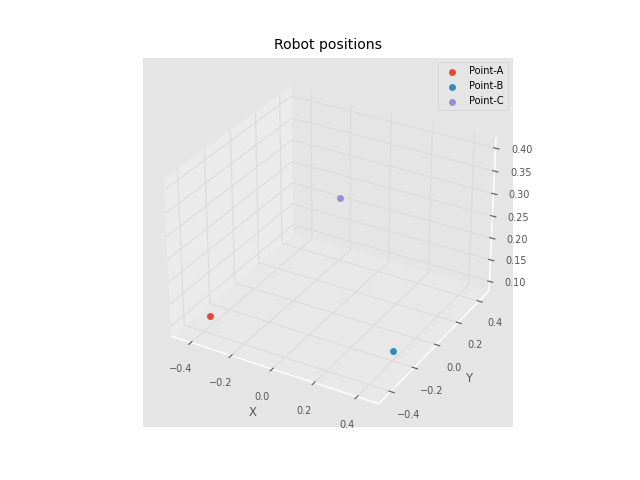

In [59]:
import matplotlib.pyplot as plt

a_x, a_y,a_z = -0.4, -0.35, 0.1
b_x, b_y, b_z = 0.4, -0.2, 0.1
c_x, c_y, c_z = 0.15, -0.2, 0.40

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(a_x,a_y,a_z,)
ax.scatter(b_x,b_y,b_z)
ax.scatter(c_x, c_y,c_z)
plt.title("Robot positions")
plt.xlim([-0.5,0.5])
plt.ylim([-0.5,0.5])
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(['Point-A','Point-B','Point-C'])
plt.show()

Next, we need to determine the joint positions for both the start coordinate and the end coordinate, which can be solved with inverse kinematics. We can use the `.ikine_LM(T)`

In [ ]:
# Rotation matrix for Rx(π)
R = np.array([
    [1, 0, 0],
    [0, -1, 0],
    [0, 0, -1]
])

# A pose: pointing downward and translated
T_a = np.eye(4)
T_a[:3, :3] = R
T_a[:3, 3] = [a_x, a_y, a_z]

# B pose: same orientation, new position
T_b = np.eye(4)
T_b[:3, :3] = R
T_b[:3, 3] = [b_x, b_y, b_z]

# C pose: same orientation, new position
T_c = np.eye(4)
T_c[:3, :3] = R
T_c[:3, 3] = [c_x, c_y, c_z]

# Calculate robot configuration with inverse kinematics
sol_a = robot.ikine_LM(T_a)
sol_b = robot.ikine_LM(T_b)
sol_c = robot.ikine_LM(T_c)

# Print solutions
print("\nA: Found Joint Solution:\n", sol_a.q)
print("\nB: Found Joint Solution:\n", sol_b.q)
print("\nC: Found Joint Solution:\n", sol_c.q)

# Verify position with forward kinematics
t_check_a = robot.fkine(sol_a.q)
t_check_b = robot.fkine(sol_b.q)
t_check_c = robot.fkine(sol_c.q)

# Print check
print(f"\nA: Check Pose:\n [ {a_x} {a_y} {a_z} ]\n",np.round(t_check_a.t,3))
print(f"\nB: Check Pose:\n [ {b_x} {b_y} {b_z} ]\n",np.round(t_check_b.t,3))
print(f"\nC: Check Pose:\n [ {c_x} {c_y} {c_z} ]\n",np.round(t_check_c.t,3))



A: Found Joint Solution:
 [-2.17363056 -2.73753825 -0.66731941 -1.30753132  1.57079633  2.53875842]

B: Found Joint Solution:
 [-0.16624292  2.598734    1.43560215 -2.46353974  1.57079629 -1.73703925]

C: Found Joint Solution:
 [-0.37551978 -1.32769036 -1.30481186 -2.07988675  1.57079633 -1.94631611]

A: Check Pose:
 [ -0.4 -0.35 0.1 ]
 [-0.4  -0.35  0.1 ]

B: Check Pose:
 [ 0.4 -0.2 0.1 ]
 [ 0.4 -0.2  0.1]

C: Check Pose:
 [ 0.15 -0.2 0.4 ]
 [ 0.15 -0.2   0.4 ]


Next we can find the trajectory based on these joint configurations

In [ ]:
# Trajectories based on error, velocity, acceleration and time
from numpy import linspace


distance = sol_b.q - sol_a.q
print("Distance of each joint:\n",distance)

# Find largest distance to determine the scaling of velocity between joints
highest = distance[0]
idx = 0
for d in distance:
    if abs(d) > abs(highest):
        highest = abs(d)
        highest_joint = idx 
    idx = idx + 1
         
print(f"Highest distance joint: {highest_joint}\n",highest)

# Determine steps from A -> B
steps_size = 0.05 # in time
duration = 5
steps = int(duration / steps_size)

# Rate of change for each joint
steps_pr_joint = linspace(sol_a.q,sol_b.q,steps)


# print("Steps for joint 1 \n",steps_pr_joint)


Distance of each joint:
 [-0.04544412 -3.06946712  1.63399554 -1.706121    3.14159264 -3.18703677]
Highest distance joint: 5
 3.1870367686636474


Shape of trajectory:  (50, 6)


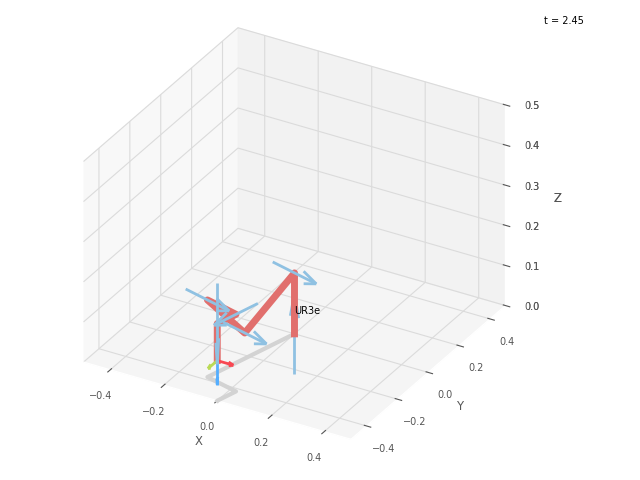

PyPlot3D backend, t = 2.499999999999999, scene:
  robot: Text(0.0, 0.0, 'UR3e')

In [ ]:
# Generate trajectory
from numpy import linspace


time_step = 0.05 # Seconds pr step
duration = 2.5 # seconds
steps = int(duration / time_step)
traj = rtb.jtraj(sol_a.q, sol_b.q,steps)

print("Shape of trajectory: ", traj.q.shape)

# Visualize
robot.plot(traj.q, backend='pyplot',limits=[-0.5,0.5,-0.5,0.5,0,0.5])

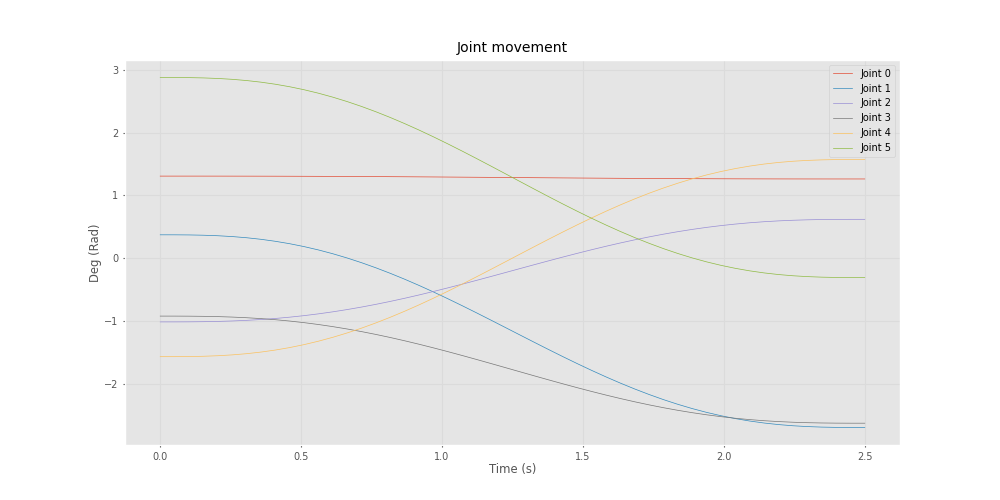

In [6]:
import matplotlib.pyplot as plt


t = linspace(0,duration,steps)

plt.figure(figsize=(10, 5))
# plt.plot(t,traj.q)
for i in range(traj.q.shape[1]):  # Loop over each joint
    plt.plot(t, traj.q[:, i], label=f'Joint {i}')
plt.xlabel("Time (s)")
plt.ylabel("Deg (Rad)")
plt.title("Joint movement")
plt.legend()

## Prepare the message for the broker

### 1. Connect to broker

In [7]:
import numpy as np
from communication import protocol
from communication.rabbitmq import Rabbitmq

# Initialize RabbitMQ connection (adjust parameters as needed)
try:
    rmq = Rabbitmq(
        ip="localhost",
        port=5672,
        username="incubator",
        password="incubator",
        # username="ur3e",
        # password="ur3e",
        vhost="/",
        exchange="UR3E_AMQP",
        type="topic",
    )
    rmq.connect_to_server()
    print("✓ Connected to RabbitMQ successfully")
except Exception as e:
    print(f"✗ Failed to connect to RabbitMQ: {e}")
    print("\nMake sure RabbitMQ is running. You can start it with:")
    print("  python -m startup.start_docker_rabbitmq")

def send_control_message(rmq, msg):
    """Send a control message to the UR3e Mockup via RabbitMQ."""
    try:
        rmq.send_message(
            routing_key=protocol.ROUTING_KEY_CTRL,
            message=msg
        )
        print(f"✓ Control message: {msg} sent successfully")
    except Exception as e:
        print(f"✗ Failed to send control message: {e}")

✗ Failed to connect to RabbitMQ: 

Make sure RabbitMQ is running. You can start it with:
  python -m startup.start_docker_rabbitmq


### Control message

In [ ]:
start_position = sol_a.q
end_position = sol_b.q

pos = [1.30559865, -0.57250228,  1.01692766, -2.01522173, -1.57079632,
        2.87639498]

vel = 60 # deg/s
acc = 80 # deg/s²

msg = {
    protocol.CtrlMsgKeys.TYPE: protocol.CtrlMsgFields.LOAD_PROGRAM,
    protocol.CtrlMsgKeys.JOINT_POSITIONS: [end_position],
    protocol.CtrlMsgKeys.MAX_VELOCITY: vel,
    protocol.CtrlMsgKeys.ACCELERATION: acc,
}

send_control_message(rmq, msg)

# send control message for starting program
msg_start = {
    protocol.CtrlMsgKeys.TYPE: protocol.CtrlMsgFields.PLAY,
}

send_control_message(rmq, msg_start)

✗ Failed to send control message: 'NoneType' object has no attribute 'basic_publish'
✗ Failed to send control message: 'NoneType' object has no attribute 'basic_publish'
